In [53]:
import numpy as np
import numpy.random as random
import matplotlib.pyplot as plt
import pickle, gzip, urllib.request, json

In [54]:
#To ensure reproducibility
random.seed(11)
np.random.seed(11)

In [55]:
# Load the dataset
with gzip.open('mnist.pkl.gz', 'rb') as f:
    train_set, valid_set, test_set = pickle.load(f, encoding='latin1')

# Get the data into arrays
images = train_set[0]
labels = train_set[1]

# Put aside an array for the patterns
patterns = np.zeros((10,784))
    
# Set aside one image per class to store (10 images in total)
for category in range(10):
    inclass = [i for i in range(labels.shape[0]) if labels[i] == category]
    patterns[category,:] = 1.0*(images[inclass[random.randint(0,len(inclass))],:] > 0)

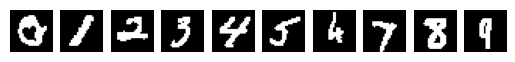

In [56]:
#Plot the patterns we're going to store
fig, axs = plt.subplots(1,10)
for c in range(10):
    axs[c].imshow(patterns[c,:].reshape((28,28)), cmap='gray')
    axs[c].axis("off")
plt.show()

In [ ]:
class hopfield_network(object):
    """
    Define a class for a Hopfield network here.
    You must also define the functions below, but you can add additional arguments, etc.
    Also, note that you are welcome to write your own helper functions. 
    Reminder: you should use numpy functions for vector and matrix operations. No autograd!
    """
    
    # The initialization function for the hopfield network
    def __init__(self,N,learning_rate = 0.001, thresh_learning_rate=0.05):
        """
        A function to initialize the hopfield network class
        
        Parameters
         - N: the number of units
         - learning_rate: the learning rate for weight updates
         - learning_rate_thresh: the learning rate for threshold updates
        """
        

        self.N = N 

        self.state = np.zeros((N,)) #Current state of the network
 
        self.weights = np.zeros((N,N))

        self.threshold = np.zeros((N,)) 

        self.learning_rate = learning_rate 

        self.threshold_learning_rate = thresh_learning_rate 
  
    
    # The function for setting the activity state of the network
    def set_state(self,activity):
        """
        set_state(activity)
        
        Sets the state of the network to the pattern given by activity.
        
        You do not need to change this function.
        """
        activity = 2*activity-1 #change from {1,0} to {1,-1}
        # set the state to activity
        self.state = activity
        
    # The function for updating the state of the network
    def update(self):
        """
        Updates the state one random neuron at a time
        """

        i = np.random.randint(0,self.N)

        #fined the signed of the weighted sum of inputs minus the threshold of this neuron
        activation = np.sign(np.dot(self.weights[i,:], self.state) - self.threshold[i])
       
        if(activation == 0 ): #ensure there are no zeros in the network
            activation = 1
        
        self.state[i] = activation #update the activation of this neuron

        return self.state



    # The function for storing one image at a time
    def store_one(self,image,gd=False,epochs=10):
        """
        Store a pattern 

        Parameters:
        - image: Binary vector of size N.
        - gd: If True, uses adaptive GD updates: default fase
        - epochs: Number of updates per pattern in GD. Default 10
        """
        #Convert image {1,0} to {1,-1}
        image = 2*image -1 
        
        
        if(gd):
            self.gd_one(epochs,image, eta=self.learning_rate)
        else:
            # Outer product update (Hebbian learning)
            self.weights += np.outer(image, image)

        # Ensure no self connections
       
 
    # The function for storing multiple images in one shot
    def store_multi(self, images, epochs=100):
        """
        Store multiple patterns using adaptive learning rate and decay.

        Parameters:
        - images: List of length N binary vectors.
        - epochs: Number of updates per pattern in SGD.
        """
        
        # Shuffle patterns to avoid last one dominating
        images = np.random.permutation(images) 

        images = np.array([2 * img - 1 for img in images])  # convert from {1,0} to {1,-1}

        self.gd_multi(epochs, images, self.learning_rate)
       
       
    
    def gd_one(self, epochs, pattern, eta, eta_theta = 0.0005, epsilon = 1e-6):
        """
        Store one pattern using gradient descent

        parameters:
        - epochs: Controls how many updates the gradient descent performs
        - pattern: The image to be stored in the network
        - eta: The learning rate for weight updates
        - eta_theta: The learning rate for threshold updates
        - epsilon: a tolerance to stop the function if function has converged.

        """
        for epoch in range(epochs):  
            #compute and perform weight update
            delta_w = eta * np.outer(pattern, pattern) 
            self.weights += delta_w 

            #compute and perform threshold update
            delta_theta = eta_theta * pattern
            self.threshold -= delta_theta
            
            #if change is below a threshold
            if(abs(np.linalg.norm(delta_w))<epsilon):
                
                (f"BREAKING AT EPOCH {epoch}")
                break
       
        np.fill_diagonal(self.weights, 0) #Ensure no self connections


    def gd_multi(self, epochs, patterns, eta, eta_theta = 0.05, epsilon = 1e-6):
        """
        Store several patterns using gradient descent

        parameters:
        - epochs: Controls how many updates the gradient descent performs
        - patterns: The images to be stored in the network
        - eta: The learning rate for weight updates
        - eta_theta: The learning rate for threshold updates
        - epsilon: a tolerance to stop the function if function has converged.
        """
        
        for epoch in range(epochs): 
            #Update the weights for each pattern
            for pattern in patterns: 
                delta_w = eta * np.outer(pattern, pattern) 
                self.weights += delta_w 
            
            #update the thresholds based on the sum of all the weights
            delta_theta = eta_theta * np.sum(patterns, axis=0)  
            self.threshold -= delta_theta

            #if change is below a threshold
            if(abs(np.linalg.norm(delta_w))<epsilon):
                print(f"BREAKING AT EPOCH {epoch}")
                break

        np.fill_diagonal(self.weights, 0) #ensure no self connections


In [58]:
# Some helper functions for generating test images

# The function for generating a noisy version of an image
def image_noise(image,noise_level=0.1):
    """
    new_image = test_noise(image)
        
    This function takes an image, adds noise to it, and returns it. 

    noise_level - between 0-1, try experimenting with this

    """
    
    # create a mask for adding noise to the image
    image_mask = random.uniform(size=image.shape) < noise_level
    
    return np.logical_xor(image,image_mask)
    
# The function for generating a combo of two images
def image_combo(image1,image2,image1_weight=0.5):
    """
    newimage = test_combo(image1,image2)
        
    This function takes a pair of images, combines them, and returns the result.
    
    image1_weight - between 0-1, try experimenting with this

    """
    
    # create a mask for mixing the images
    image1_mask = random.uniform(size=image1.shape) < image1_weight
        
    return image1_mask*image1 + (1-image1_mask)*image2

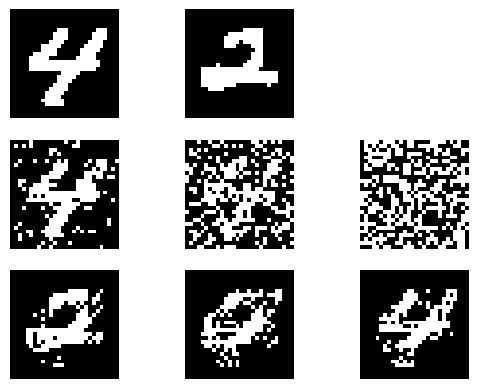

In [59]:
# Test the helper functions to make sure they work

# Pick some random images
image1 = patterns[random.randint(0,10)]
image2 = patterns[random.randint(0,10)]

# Create a little array for storage
test_images = np.zeros((2,3,784))

# Generate a series of noise images
test_images[0,0,:] = image_noise(image1)
test_images[0,1,:] = image_noise(image1,noise_level=0.3)
test_images[0,2,:] = image_noise(image1,noise_level=0.5)

# Generate a series of combo images
test_images[1,0,:] = image_combo(image1,image2,image1_weight=0.2)
test_images[1,1,:] = image_combo(image1,image2)
test_images[1,2,:] = image_combo(image1,image2,image1_weight=0.8)

# Plot the images, plus the originals on top
fig, axs = plt.subplots(3,3)
axs[0,0].imshow(image1.reshape((28,28)), cmap='gray')
axs[0,0].axis("off")
axs[0,1].imshow(image2.reshape((28,28)), cmap='gray')
axs[0,1].axis("off")
axs[0,2].axis("off")
for c in range(3):
    axs[1,c].imshow(test_images[0,c,:].reshape((28,28)), cmap='gray')
    axs[1,c].axis("off")
    axs[2,c].imshow(test_images[1,c,:].reshape((28,28)), cmap='gray')
    axs[2,c].axis("off")
plt.show()

## Choose how many patterns to store and choose which patterns to store

In [ ]:

one_pattern = False # flag for whether to store one pattern at a time

multi_upper = 10 #Upper bound for the image(s) we want to store (non-inclusive)
multi_lower = 8 #Lower bound for the image(s) we want to store 

## Intialize and train the Hopfield Network

In [ ]:
hnet = hopfield_network(784,0.01) # construct the network with 784 neurons and learning rate of 0.01

rand_image = patterns[random.randint(multi_lower,multi_upper),:] #ensure that stored pattern is the one that is tested

if one_pattern:
    # Train the network to store one the patterns using your store_one function
    hnet.store_one(rand_image,True)
else:
    # Train the network to store all the patterns using your store_multi function 
    hnet.store_multi(patterns[multi_lower:multi_upper],True)

# Test how well the network can recall the single image it stored
### Can test on noisy image, combo image, or noisy combo image please uncomment the appropriate lines

0
1000
2000
3000
4000
5000


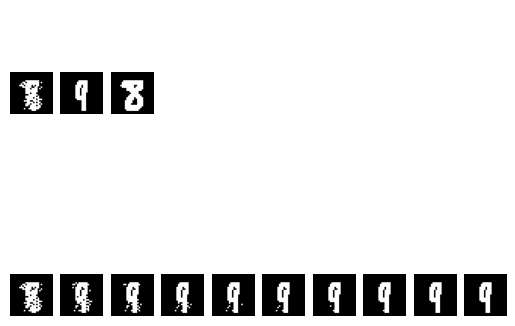

In [ ]:
# Plot generated images from your Hopfield network as it updates after receiving an initial pattern that is
# a noisy version of an image that was stored

# number of time-steps to run the network for
numsteps = int(784*np.log(784)) # feel free to change this

# create an array for storing activity states over time
activity = np.zeros((numsteps,784))


# (1) TEST USING NOISY IMAGE
# activity[0,:] = image_noise(rand_image)
# hnet.set_state(activity[0,:])

# (2) TEST ON COMBINED IMAGE

rand_image2 = patterns[random.randint(0,10),:]
activity[0,:] = image_combo(rand_image,rand_image2)

# (3) TEST ON NOISY COMBINED IMAGE
#activity[0,:] = image_noise(image_combo(rand_image,rand_image2))

hnet.set_state(activity[0,:]) #Set initialize state

#update the states iteratively until convergence
for t in range(numsteps-1):
    activity[t+1,:] = hnet.update()
   
    if(t % 1000 ==0): #mark progress
        print(t)

# plot the results 
fig, axs = plt.subplots(2,10)
axs[0,0].imshow(activity[0,:].reshape((28,28)), cmap='gray')
axs[0,1].imshow(rand_image.reshape((28,28)), cmap='gray')
axs[0,2].imshow(rand_image2.reshape((28,28)), cmap='gray')
for c in range(0, 10):
    axs[1,c].imshow(activity[int(numsteps * c/10),:].reshape((28,28)), cmap='gray')
    axs[0,c].axis("off")
    axs[1,c].axis("off")
plt.show()   

# Test how well the network can recall the one of the images it stored
### Can test on noisy image, combo image, or a noisy combo image please uncomment the appropriate lines

0
1000
2000
3000
4000
5000


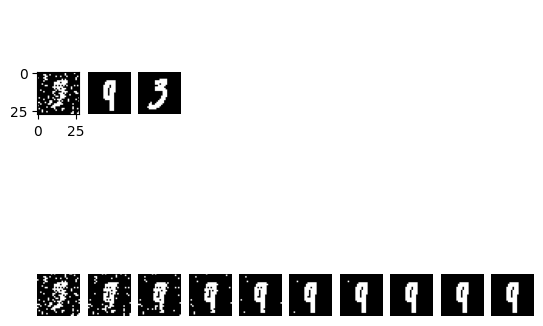

In [ ]:
# Plot generated images from your Hopfield network as it updates after receiving an initial pattern that is
# a combination of two images that were stored

# number of time-steps to run the network for
numsteps = int(784*np.log(784)) # feel free to change this

# create an array for storing activity states over time
activity = np.zeros((numsteps,784))

# test using a combo of two random images
rand_image1 = patterns[random.randint(multi_lower, multi_upper),:]
rand_image2 = patterns[random.randint(0, 10),:]

# (1) TEST ON NOISY IMAGE
#activity[0,:] =  image_noise(rand_image1)

# (2) TEST ON COMBINED IMAGE
# activity[0,:] = image_combo(rand_image,rand_image2)

# (3) TEST ON NOISY COMBINED IMAGE
activity[0,:] = image_noise(image_combo(rand_image1,rand_image2))

hnet.set_state(activity[0,:]) #set initial state

for t in range(numsteps-1):
    activity[t+1,:] = hnet.update()
    if(t % 1000 ==0): #mark progress
        print(t)

# plot the results at 10%, 20%, etc... and final image
fig, axs = plt.subplots(2,10)
axs[0,0].imshow(activity[0,:].reshape((28,28)), cmap='gray')
axs[0,1].imshow(rand_image1.reshape((28,28)), cmap='gray')
axs[0,2].imshow(rand_image2.reshape((28,28)), cmap='gray')
axs[1,0].imshow(activity[0,:].reshape((28,28)), cmap='gray')
axs[1,0].axis("off")
for c in range(1, 10):
    axs[1,c].imshow(activity[int(numsteps * c/10),:].reshape((28,28)), cmap='gray')
    axs[0,c].axis("off")
    axs[1,c].axis("off")
plt.show()   